# Lecture 10 - Genetic Algorithm MPI Parallelization

### Exercise 10.1

Choose **ONLY ONE** of the two following possibilities:

1. Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

2. Starting from your Genetic Algorithm code implement a **Parallel Tempering algorithm** (Simulated Annealing with many temperatures). Parallelize with MPI libraries your algorithm in order to solve the TSP where each computing node, up to 11, is characterized by a different temperature or a limited set of temperatures (if you need more than 11 temperatures). Use your genetic operators (except crossover) as trial moves for the Metropolis algorithm and **add a trial move that proposes an exchange of paths among adjacent temperatures (nodes)** (see lecture 8 for the acceptance formula). The candidate solution of the TSP will appear on the node with the lowest temperature.

### Exercise 10.2

Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.

If your choice in Exercise 10.1 is option 1, do you improve with respect using the same number of computing cores but with **independent GA searches** ?

If your choice in Exercise 10.1 is option 2, by using a number of temperatures equal to the number of individuals in your **non-parallel Genetic Algorithm code**, do you "improve" with respect to it?

### Exercises 10.1/10.2 - Theory and solution



*In this notebook the goal is to employ parallel computing to speed up our Genetic Algorithm code produced in Lecture 9.*

#### Parallel computing and MPI library
The core idea of parallel computing is to split a single application code to run across multiple processors. 
The goal is to reduce the total computational time, in fact in principle if the number of CPU is $p$ and the total time of execution is $t$, the time can be reduced to $t_p = \frac{t}{p}$.

In this code a SPMD (SingleProgramMultipleData) model is implemented. In this kind of model there is only one program and each process uses the same executable working on different sets of data.

To distinguish between processes, each process has a unique integer called rank. You can let processes behave differently by using the value of rank.

In this code we decided to parallelize the previous algorithm using the Message Passing Interface (MPI).
When we include 'mpi.h' we define the object MPI_COMM_WORLD which represents the group consisting of all the processes participating in the parallel job.
In the MPI library everything can be obtained via the following instructions:
* `MPI_Init()` $\rightarrow$ used for initializing an MPI environment, it must be called once only before calling any other function.
* `MPI_Finalize()` $\rightarrow$ terminates MPI processing and no other MPI call can be made afterwards.
* `MPI_Comm_size()` $\rightarrow$ returns the number of processes belonging to the MPI_COMM_WORLD object.
* `MPI_Comm_rank()` $\rightarrow$ returns the rank of the process within the communicator given as the first argument.
* `MPI_Send()` $\rightarrow$ to send a message.
* `MPI_Recv()` $\rightarrow$ to receive a message.

#### Code
In this code 8 cores were used to carry out two kinds of simulations
1. With migrations $\rightarrow$  every $N_{mig}$ generations the best individual of each continent is exchanged randomly with another continent
2. Without migrations  
Result: the genetic algorithm performed better when migrations were used.

The following values were defined for the optimization
| Parameter | Value | Role |
| :--- | :--- | :--- |
| **$N_{cities}$** | $110$ | Number of italian regional capitals|
| **$N_{pop}$** | $700$ | Number of candidate solutions per generation |
| **$N_{gen}$** | $4000$ | Total number of generations |
| **$N_{mig}$** | $50$ | Number of generations between two consecutive migrations |
| **$P_{mutation}$** | $0.10$ | Probability for each individual mutation operator |




In [33]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import cartopy.feature as cfeature

Best path length (without migrations): 67.78
Best path length (with migrations): 65.91


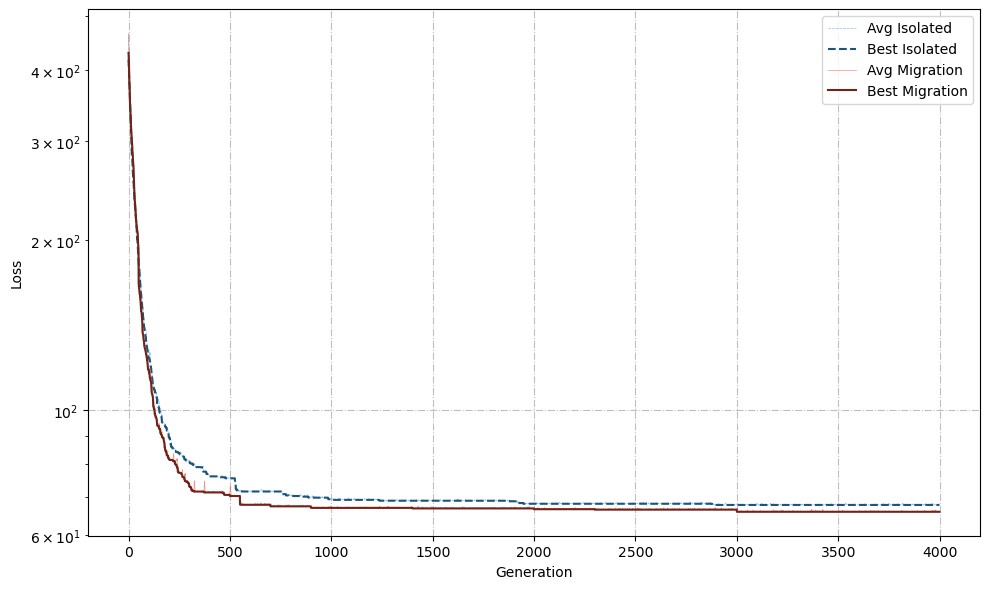

In [35]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

path_iso = "isolated/italy_losses_rank0.dat"
if os.path.exists(path_iso):
    d = np.loadtxt(path_iso)
    plt.plot(d[:, 0], d[:, 2], color='#3498db', alpha=0.6, linestyle='--', linewidth=0.5, label='Avg Isolated')
    plt.plot(d[:, 0], d[:, 1], color='#1c557b', linestyle='--', linewidth=1.5, label='Best Isolated')
    print(f"Best path length (without migrations): {d[-1, 1]:.2f}")

path_mig = "migration/italy_losses_rank0.dat"
if os.path.exists(path_mig):
    d = np.loadtxt(path_mig)
    plt.plot(d[:, 0], d[:, 2], color='#e74c3c', alpha=0.6, linestyle='-', linewidth=0.5, label='Avg Migration')
    plt.plot(d[:, 0], d[:, 1], color='#712219', linestyle='-', linewidth=1.5, label='Best Migration')
    print(f"Best path length (with migrations): {d[-1, 1]:.2f}")

plt.xlabel("Generation")
plt.ylabel("Loss")
plt.yscale('log')
plt.grid(True, linestyle='-.', alpha=0.5, color='gray') 
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.show()

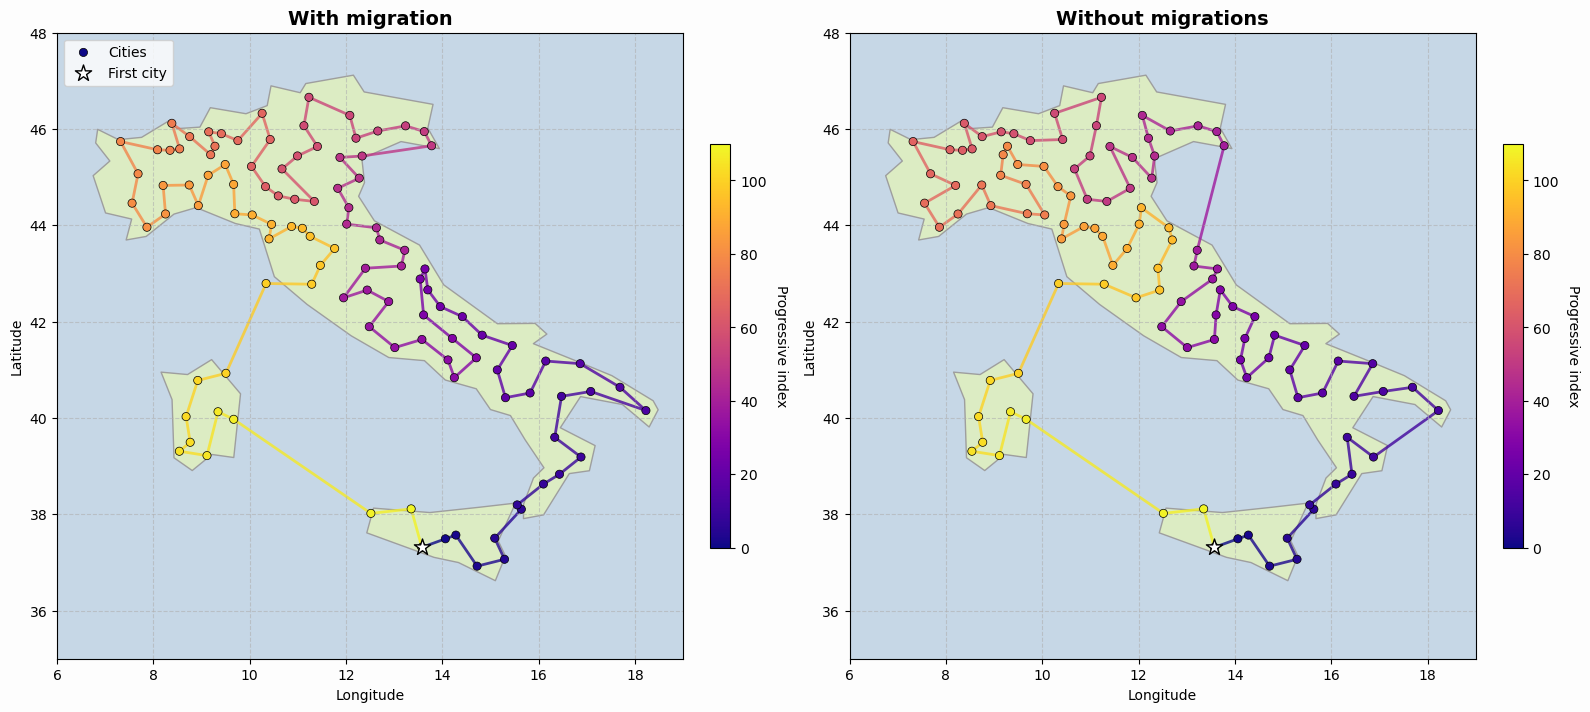

In [36]:
def plot_tsp_italy_comparison(file_migration, file_isolated):

    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    try:
        world = gpd.read_file(url)
        italy = world[world['NAME'] == "Italy"]
    except Exception as e:
        print(f"Errore nel caricamento della mappa: {e}")
        return

    files = [file_migration, file_isolated]
    titles = ["With migration", "Without migrations"]
    fig, axes = plt.subplots(1, 2, figsize=(16, 10), facecolor='#fdfdfd')
    
    for i, (ax, filename) in enumerate(zip(axes, files)):
        ax.set_facecolor("#c6d7e6") 
        italy.plot(ax=ax, color="#dcecc3", edgecolor='#9e9e9e', linewidth=1, zorder=0)

        if os.path.exists(filename):
            data = np.loadtxt(filename)
            lon = data[:, 0]
            lat = data[:, 1]
            num_points = len(lon)

            for j in range(num_points - 1):
                color = plt.cm.plasma(j / num_points)
                ax.plot(lon[j:j+2], lat[j:j+2], color=color, lw=2, zorder=1, alpha=0.8)

            sc = ax.scatter(lon, lat, 
                            c=np.arange(num_points), 
                            cmap='plasma', 
                            s=35, 
                            edgecolors='black', 
                            linewidths=0.5, 
                            zorder=2, 
                            label='Cities')

            ax.scatter(lon[0], lat[0], c='white', s=150, edgecolors='black', 
                        marker='*', zorder=3, label='First city')
            
            cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
            cbar.set_label('Progressive index', rotation=270, labelpad=15)
        else:
            ax.text(0.5, 0.5, f"File not found:\n{filename}", 
                    ha='center', va='center', transform=ax.transAxes)

        ax.set_title(titles[i], fontsize=14, fontweight='bold')
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim([6, 19])
        ax.set_ylim([35, 48])
        ax.set_aspect('equal')
        ax.grid(True, linestyle='--', alpha=0.6)
        if i == 0:
            ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig("tsp_comparison_italy.png")
    plt.show()

if __name__ == "__main__":
    plot_tsp_italy_comparison(
        "migration/italy_best_path_rank0.dat", 
        "isolated/italy_best_path_rank0.dat"
    )

### Extra - Travel Salesman Problem using UN World capitals 

*Here a code to compute the Travel Salesman Problem for the UN recognized world capitals is presented.*

The Earth has been approximated to a perfect sphere and so the distances must be computed using the non-Euclidean distance of 2 points that lay on a sphere.

To implement this distance, the code utilizes the Haversine formula, which determines the great-circle distance between two points on a sphere given their longitudes and latitudes. The mean radius is 6371.0 km.

To do this a few steps are needed:

- Latitudes ($\phi$) and longitudes ($\lambda$) must be converted from degrees to radians because trigonometric functions in C++ (and most math) expect radians
$$
\text{radians} = \text{degrees} \times \frac{\pi}{180}
$$
- We calculate the square of half the chord length between the two points:
$$
a = \sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)$$
Where $\Delta\phi$ is the difference in latitude and $\Delta\lambda$ is the difference in longitude.
- The angular distance in radians is computed using the $atan2$ function (i.e. 2-argument arctangent function), which is more stable than the arcsine
$$
c = 2 \cdot \operatorname{atan2}(\sqrt{a}, \sqrt{1-a})
$$
- In the end we have to multiply the angular distance by the Earth's radius
$$
d = R \cdot c
$$

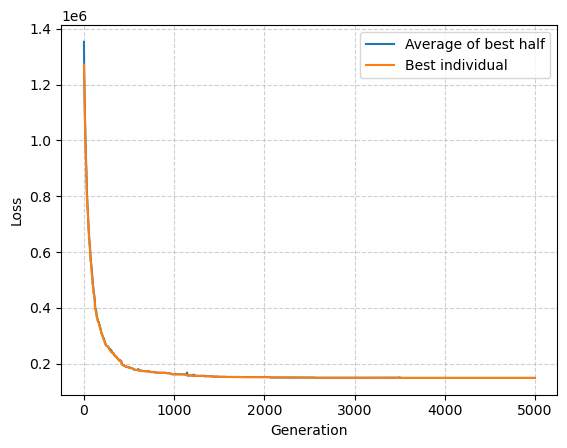

In [41]:
data = np.loadtxt("3d/world_losses.dat")
gen = data[:, 0]
best_loss = data[:, 1]
ave_loss = data[:, 2]

plt.plot(gen, ave_loss, label='Average of best half')
plt.plot(gen, best_loss, label='Best individual')

plt.xlabel("Generation")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


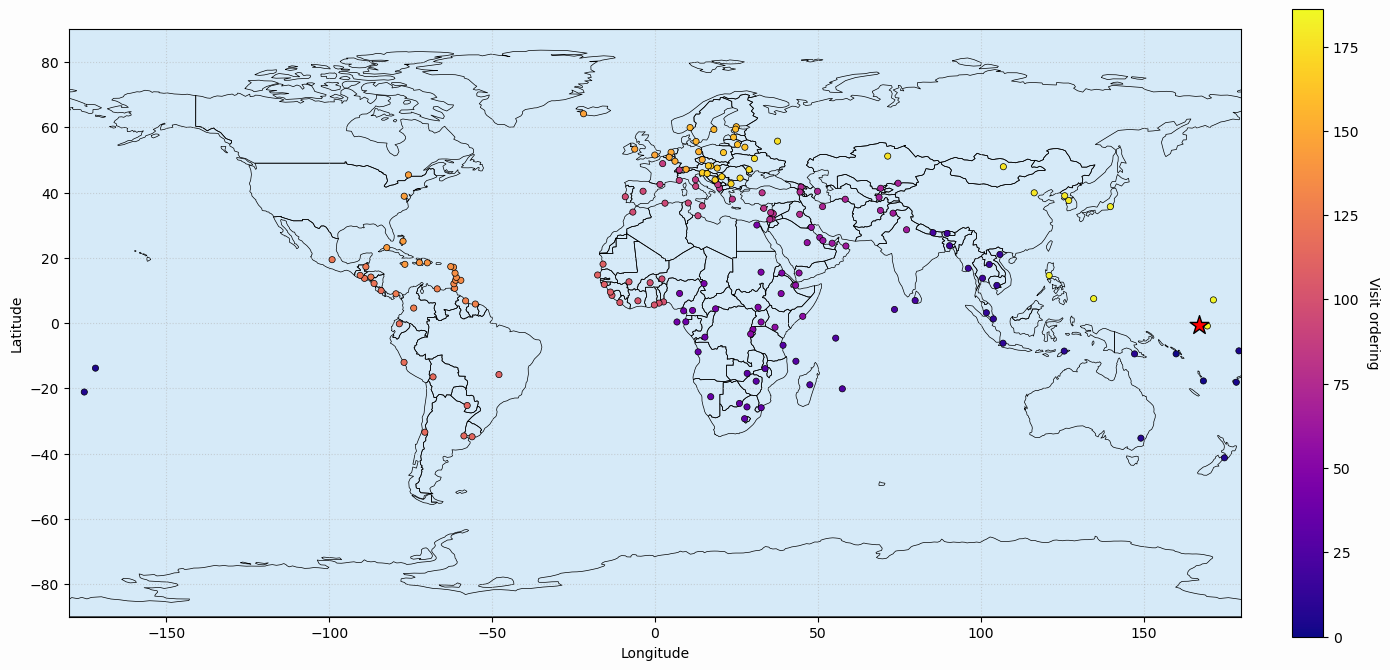

In [42]:
def plot_2d_world_tsp_with_borders(filename):
    # Dataset Natural Earth (confini globali)
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

    try:
        world = gpd.read_file(url)
    except Exception as e:
        print(f"Errore nel caricamento della mappa: {e}")
        return

    # Caricamento dati (lat, lon)
    data = np.loadtxt(filename)
    lat = data[:, 0]
    lon = data[:, 1]
    num_points = len(lon)

    fig, ax = plt.subplots(figsize=(14, 7), facecolor='#fdfdfd')
    ax.set_facecolor("#d6eaf8")  
    
    world.boundary.plot(
        ax=ax,
        linewidth=0.5,
        color="black",
        zorder=1
    )

    for i in range(num_points - 1):
        x1, x2 = lon[i], lon[i+1]
        y1, y2 = lat[i], lat[i+1]

    sc = ax.scatter(
        lon, lat,
        c=np.arange(num_points),
        cmap='plasma',
        s=20,
        edgecolors='black',
        linewidths=0.5,
        zorder=3
    )

    ax.scatter(
        lon[0], lat[0],
        color='red',
        marker='*',
        s=200,
        edgecolors='black',
        zorder=4,
        label='Start'
    )
    ax.set_xlim([-180, 180])
    ax.set_ylim([-90, 90])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = plt.colorbar(sc, ax=ax, fraction=0.025, pad=0.04)
    cbar.set_label('Visit ordering', rotation=270, labelpad=15)

    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    plot_2d_world_tsp_with_borders("3d/world_best_path_rank0.dat")

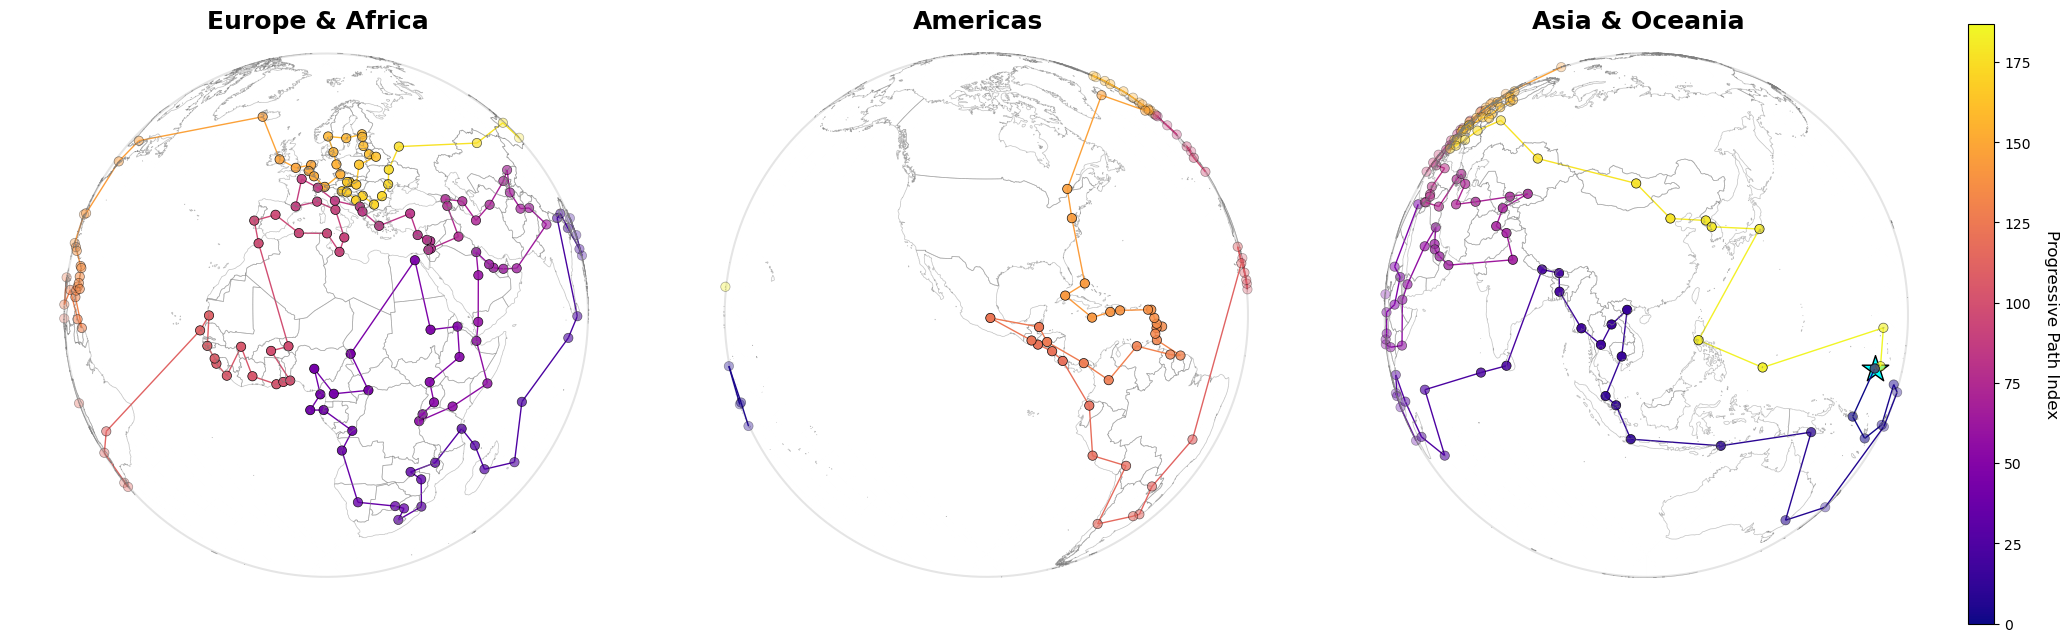

In [ ]:
filename = "3d/world_best_path_rank0.dat"
try:
    data = np.loadtxt(filename)
    lat_rad = np.radians(data[:, 0])
    lon_rad = np.radians(data[:, 1])
    
    points_all = np.vstack((
        np.cos(lat_rad) * np.cos(lon_rad),
        np.cos(lat_rad) * np.sin(lon_rad),
        np.sin(lat_rad)
    )).T
    num_points = len(points_all)
except Exception as e:
    print(f"Errore caricamento file: {e}")
    exit()

shapefile = cfeature.NaturalEarthFeature('cultural', 'admin_0_countries', '50m')
geometries = list(shapefile.geometries())

views = [
    ("Europe & Africa", 20, 10),
    ("Americas", 20, -100),
    ("Asia & Oceania", 20, 110)
]

fig = plt.figure(figsize=(22, 10), facecolor='white')

for i, (title, elev, azim) in enumerate(views):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    ax.dist = 7.5 
    phi_cam = np.radians(elev)
    theta_cam = np.radians(azim)
    camera_vec = np.array([np.cos(phi_cam) * np.cos(theta_cam), 
                           np.cos(phi_cam) * np.sin(theta_cam), 
                           np.sin(phi_cam)])

    t = np.linspace(0, 2*np.pi, 200)

    if abs(camera_vec[2]) < 0.9: 
        v1 = np.cross(camera_vec, [0, 0, 1])
    else:
        v1 = np.cross(camera_vec, [0, 1, 0])
    v1 /= np.linalg.norm(v1)
    v2 = np.cross(camera_vec, v1)
    v2 /= np.linalg.norm(v2)
    
    rim_points = np.array([np.cos(ti)*v1 + np.sin(ti)*v2 for ti in t])
    ax.plot(rim_points[:,0], rim_points[:,1], rim_points[:,2], color='black', linewidth=1.5, zorder=2, alpha=0.1)

    # map
    world_segments = []
    for geometry in geometries:
        parts = geometry.boundary.geoms if hasattr(geometry.boundary, 'geoms') else [geometry.boundary]
        for line in parts:
            coords = np.array(line.coords)
            if len(coords) < 2: continue
            l_lon, l_lat = coords[:, 0], coords[:, 1]
            x_w = np.cos(np.radians(l_lat)) * np.cos(np.radians(l_lon))
            y_w = np.cos(np.radians(l_lat)) * np.sin(np.radians(l_lon))
            z_w = np.sin(np.radians(l_lat))
            w_points = np.vstack((x_w, y_w, z_w)).T
            segs = np.concatenate([w_points[:-1, np.newaxis, :], w_points[1:, np.newaxis, :]], axis=1)
            mid_p = (w_points[:-1] + w_points[1:]) / 2.0
            visibility = np.dot(mid_p, camera_vec) > 1e-2
            world_segments.extend(segs[visibility])

    if world_segments:
        lc_map = Line3DCollection(world_segments, colors='gray', linewidths=0.5, alpha=0.5, zorder=1)
        ax.add_collection3d(lc_map)

    # path
    visible_mask = np.dot(points_all, camera_vec) > 1e-3
    if len(points_all) > 1:
        path_segs = np.concatenate([points_all[:-1, np.newaxis, :], points_all[1:, np.newaxis, :]], axis=1)
        path_vis = visible_mask[:-1] & visible_mask[1:]
        path_colors = plt.cm.plasma(np.linspace(0, 1, len(path_segs)))
        lc_path = Line3DCollection(path_segs[path_vis], colors=path_colors[path_vis], linewidths=1.0, zorder=5)
        ax.add_collection3d(lc_path)

    sc = ax.scatter(points_all[visible_mask, 0], points_all[visible_mask, 1], points_all[visible_mask, 2], 
                    c=np.where(visible_mask)[0], cmap='plasma', s=45, edgecolors='black', 
                    linewidths=0.5, zorder=10, vmin=0, vmax=num_points)

    if visible_mask[0]:
        ax.scatter(points_all[0,0], points_all[0,1], points_all[0,2], 
                   color='cyan', marker='*', s=400, edgecolors='black', zorder=20)

    # zoom
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=18, fontweight='bold', y=1.05)
    ax.set_axis_off()
    
    limit = 0.7 
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect([1,1,1])
    
    u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
    ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v), 
                      color="lightgray", alpha=0.01, linewidth=0.1)
    ax.set_position([0.05 + i*0.3, 0.05, 0.28, 0.9]) 

cbar_ax = fig.add_axes([0.94, 0.2, 0.012, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Progressive Path Index', rotation=270, labelpad=20, fontsize=12)

plt.show()